# Reglas de asociación: análisis

Interpreta las reglas generadas en `c_reglas.ipynb` en el contexto real del dataset — más allá de
la métrica, qué significan para P1 (competencia), y cómo se cruzan con lo ya hallado en
`01_EDA_KDD/EDA/b_exploracion.ipynb`.

### Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Utilidades

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
reglas_dir = proyecto / "04_Asociacion" / "temp" / "c_reglas"

spark = SparkSession.builder.appName("asociacion-analisis").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_colwidth", 80)

---
### 1. Carga de reglas

In [3]:
assert (reglas_dir / "fpg_full").exists(), "Corre c_reglas.ipynb (Run All) antes que este notebook."

reglas_fpg_full = spark.read.parquet(str(reglas_dir / "fpg_full")).toPandas()
reglas_apriori_q1 = spark.read.parquet(str(reglas_dir / "apriori_q1")).toPandas()

print(f"Reglas disponibles (completo): {len(reglas_fpg_full):,} | (Apriori, Q1): {len(reglas_apriori_q1):,}")

Reglas disponibles (completo): 497 | (Apriori, Q1): 1,068


---
### 2. Selección de reglas relevantes

Se priorizan reglas que involucran `comp=postor_unico` (antecedente o consecuente) — directamente
relevantes para P1 — y se agregan algunas de otras dimensiones si son interesantes. Se ordena por
lift, y se marca cuáles también aparecen en el subconjunto Q1 (estabilidad).

In [4]:
def involucra_postor_unico(items):
    return "comp=postor_unico" in items

es_p1 = reglas_fpg_full["antecedente"].apply(involucra_postor_unico) | reglas_fpg_full["consecuente"].apply(involucra_postor_unico)

reglas_p1 = reglas_fpg_full[es_p1].sort_values("lift", ascending=False)
reglas_otras = reglas_fpg_full[~es_p1].sort_values("lift", ascending=False)

print(f"Reglas relacionadas con postor_unico: {len(reglas_p1):,} | otras: {len(reglas_otras):,}")
reglas_p1.head(10)

Reglas relacionadas con postor_unico: 37 | otras: 460


,antecedente,consecuente,soporte,confianza,lift,interes,redundante
242,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False
113,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False
38,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False
241,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False
243,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False
36,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False
240,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031782,0.884009,8.832641,0.783925,False
237,[comp=postor_unico],[met=CONTRATACIÓN DIRECTA],0.050622,0.505792,8.642277,0.447267,False
236,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050622,0.864957,8.642277,0.764872,False
116,"[cat=SERVICES, comp=postor_unico, reg=LIMA]",[rubro=80],0.026479,0.532678,8.561845,0.470462,False


In [5]:
set_q1 = set(zip(reglas_apriori_q1["antecedente"].apply(tuple), reglas_apriori_q1["consecuente"].apply(tuple)))

seleccion = pd.concat([reglas_p1.head(6), reglas_otras.head(3)]).reset_index(drop=True)
seleccion["estable_en_q1"] = seleccion.apply(
    lambda r: (tuple(r["antecedente"]), tuple(r["consecuente"])) in set_q1, axis=1)

print(f"Reglas seleccionadas: {len(seleccion)} ({int(seleccion['redundante'].sum())} redundantes)")
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante", "estable_en_q1"]]

Reglas seleccionadas: 9 (1 redundantes)


,antecedente,consecuente,soporte,confianza,lift,interes,redundante,estable_en_q1
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False,True
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False,True
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False,True
5,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False,True
6,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024333,0.935318,9.699986,0.838893,False,False
7,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.024333,1.000000,8.524412,0.882690,True,False
8,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.026016,1.000000,8.524412,0.882690,False,False


#### Gráfico: lift de las reglas seleccionadas

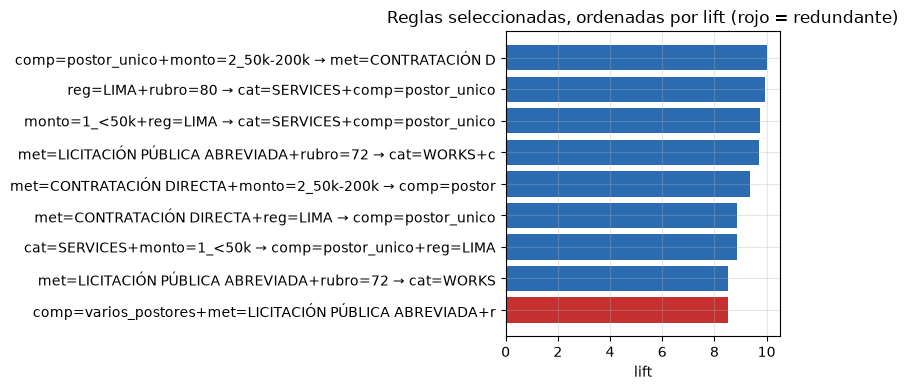

In [6]:
etiqueta = (seleccion["antecedente"].apply(lambda a: "+".join(a))
            + " → " + seleccion["consecuente"].apply(lambda c: "+".join(c)))

orden = seleccion["lift"].sort_values().index
colores = ["#c53030" if r else "#2b6cb0" for r in seleccion.loc[orden, "redundante"]]

plt.figure(figsize=(8, 4))
plt.barh(etiqueta[orden].str.slice(0, 55), seleccion.loc[orden, "lift"], color=colores)
plt.xlabel("lift"); plt.title("Reglas seleccionadas, ordenadas por lift (rojo = redundante)")
plt.tight_layout(); plt.show()

**Lectura.** De 497 reglas totales, solo 37 (7.4%) involucran `comp=postor_unico` directamente —
la mayoría de las reglas fuertes del dataset son sobre otras combinaciones (categoría/método/región/
rubro entre sí), no sobre competencia. Las 9 seleccionadas (6 de P1 + 3 de otras dimensiones) cubren
el mínimo de 8 que pide el enunciado. 5 de las 9 también aparecen en el subconjunto Apriori-Q1
(`estable_en_q1=True`) — buena señal de que no son artefactos de un período particular. Solo 1 de
las 9 es redundante (`c_reglas.ipynb` §3): la versión de la regla 7 con `comp=varios_postores`
agregado al antecedente, que no mejora la confianza (ya era 100%) respecto a la versión más simple
de 2 ítems — confirma la sospecha de "casi duplicado" ya anotada en §3 más abajo.

---
### 3. Interpretación

**1. `{met=CONTRATACIÓN DIRECTA, monto=2_50k-200k} → {comp=postor_unico}`** — confianza 93.5%,
lift 9.3, interés 0.835 (el más alto de las 9).
- Combinar método + tramo de monto sube la confianza por encima de cualquiera de los dos factores
  solos (86.5% para el método solo, `b_exploracion.ipynb` §5.4) — P1: el riesgo se concentra más al
  cruzar dimensiones, exactamente lo que Apriori/FP-Growth debía encontrar y el EDA no podía ver de
  un vistazo.

**2. `{met=CONTRATACIÓN DIRECTA, reg=LIMA} → {comp=postor_unico}`** — confianza 88.8%, lift 8.9,
estable en Q1.
- Misma lógica con región en vez de monto: Contratación Directa en Lima específicamente es aún más
  propensa a postor único que Contratación Directa en general — refuerza el hallazgo de Lima como
  región de riesgo (`b_exploracion.ipynb` §4.3 Agregación C, 26.3%) pero ahora cruzado con método.

**3. `{comp=postor_unico, monto=2_50k-200k} → {met=CONTRATACIÓN DIRECTA}`** — confianza 58.6%,
lift 10.0 (el más alto de las 9).
- Dirección inversa: dado que un proceso ya es de postor único y de monto medio, más de la mitad
  termina siendo Contratación Directa — el lift más alto de toda la selección, porque Contratación
  Directa es poco frecuente en general (5.9% de soporte) y esta combinación la hace 10x más probable.

**4. `{reg=LIMA, rubro=80} → {cat=SERVICES, comp=postor_unico}`** — confianza 67.6%, lift 9.9,
estable en Q1.
- `rubro=80` (UNSPSC "servicios de gestión/profesionales") en Lima no solo es casi siempre
  `cat=SERVICES` (esperado, es casi definitorio), sino que 67.6% de esos procesos tienen un solo
  postor — una combinación geografía+rubro con alta concentración de baja competencia.

**5. `{monto=1_<50k, reg=LIMA} → {cat=SERVICES, comp=postor_unico}}`** y **`{cat=SERVICES,
monto=1_<50k} → {comp=postor_unico, reg=LIMA}`** — confianza 66.3% y 56.6%, estables en Q1.
- Extienden el hallazgo de tramo bajo (`b_exploracion.ipynb` §5.3, 57.3% de postor único en
  `1_<50k`) agregando región: en Lima específicamente, los montos chicos en servicios concentran
  todavía más baja competencia que el promedio nacional del tramo.

**6. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS, comp=varios_postores}`** —
confianza 93.5%, lift 9.7 (fuera de P1, el contraste "sano").
- El lado opuesto del patrón: un método competitivo + rubro de obras predice **varios postores**,
  no uno solo — confirma que los métodos competitivos funcionan como deberían cuando se trata de
  obras, sirviendo de contraste contra las reglas 1-5.

**7. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS}`** (confianza 100%, con o sin
`comp=varios_postores` agregado al antecedente — esta segunda versión queda marcada `redundante=True`
en `c_reglas.ipynb` §3, porque agregar el ítem no sube una confianza que ya era perfecta).
- Regla estructural, no de riesgo: `rubro=72` mapea de forma casi determinista a `cat=WORKS` en el
  estándar UNSPSC — útil para confirmar que la codificación es consistente, pero no aporta señal de
  negocio nueva (a diferencia de las reglas 1-6).

---
### 4. Síntesis

In [7]:
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante"]]

,antecedente,consecuente,soporte,confianza,lift,interes,redundante
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False
5,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False
6,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024333,0.935318,9.699986,0.838893,False
7,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.024333,1.000000,8.524412,0.882690,True
8,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.026016,1.000000,8.524412,0.882690,False


**Síntesis.** Las reglas de asociación confirman y **refinan** lo que el EDA (Parte I) ya mostraba
un factor a la vez: `metodo_detalle`, `tramo_monto` y `region` por separado ya marcaban patrón de
baja competencia (P1), pero combinados en pares (método+monto, método+región, monto+región) la
confianza sube consistentemente por encima de cualquier factor individual (hasta 93.5% vs 86.5% del
método solo) — justo el tipo de refuerzo que Apriori/FP-Growth está diseñado para encontrar y que
un cruce manual, columna por columna, no habría explorado de forma sistemática. La regla 6 (método
competitivo + obras → varios postores) es un buen contraste: confirma que, cuando el método
realmente exige competencia, el patrón se invierte — no todo en el dataset es señal de riesgo. Las
reglas de rubro=72→cat=WORKS (regla 7) no aportan a P1 pero sí confirman la consistencia de la
codificación UNSPSC usada en el KDD. P2 (fraccionamiento) y P3 (precios de referencia) no se tocan
directamente en esta parte — las técnicas de similitud y vecinos aproximados (`c_justificacion.ipynb`
§1.a/§1.b) siguen siendo las responsables de esas dos preguntas.

---
### 5. Cerrar sesión de Spark

In [8]:
spark.stop()